# Feature Space and Classification Lab
The objectives of this lab are for you to ...
1. Conceptualize the transition from the image space to feature space
1. Visualize the feature space and to
1. Understand manifolds and discriminability in feature space
1. Experiment on this feature space with simple classifiers 
1. Assess the performance of the classifiers for visual recognition

## Libraries, data set, sanity check

In [1]:
# one-time prep work
# set matplotlib to render in this window, with the specified figure size
%matplotlib inline  
# Enable inline plotting for Jupyter notebooks
import random  # Import random number generation
import numpy as np  # Import NumPy for numerical array operations
import cv2 as cv  # Import OpenCV computer vision library
print(f"Your OpenCV Version is {cv.__version__} - please review the documentation: "
      f"https://docs.opencv.org/{cv.__version__}/")
import matplotlib.pyplot as plt  # Import pyplot for visualization

Your OpenCV Version is 4.10.0 - please review the documentation: https://docs.opencv.org/4.10.0/


The code and data for this this lab come from various key sources, including [scikit-learn](https://scikit-learn.org/stable/index.html) and OpenCV. Please spend 10 minutes to look through the [OpenCV Documentation](https://docs.opencv.org/4.9.0/) (select the version that matches what you have installed) to get an overview of the available functionality.

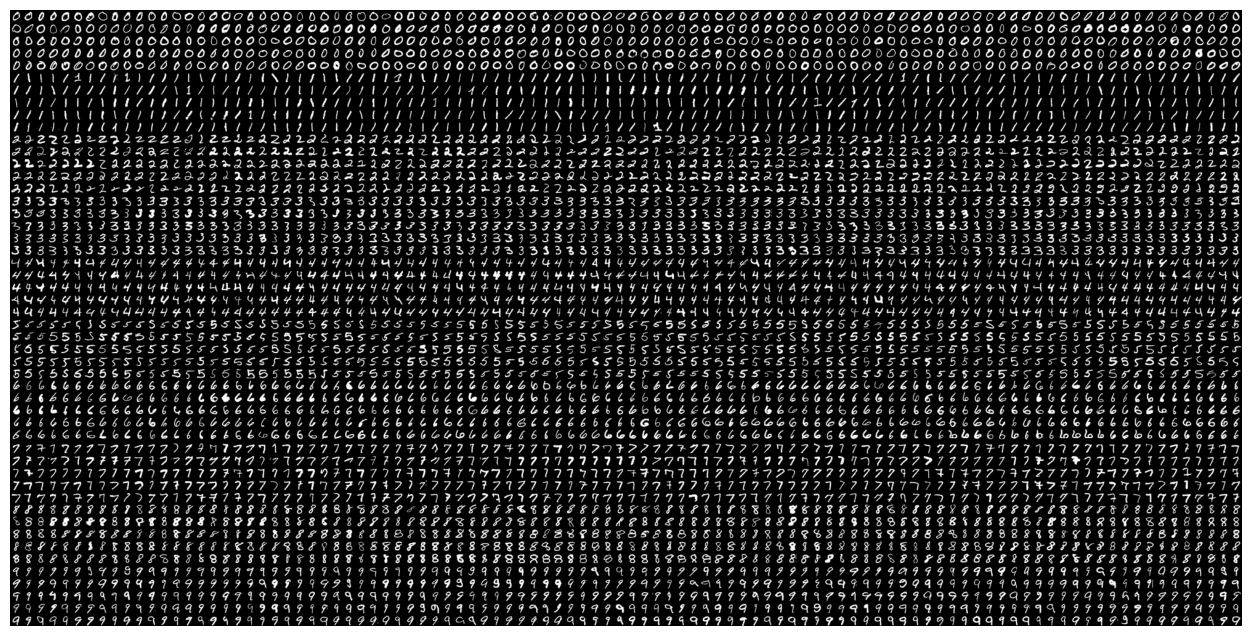

(1797, 64)
2000000


In [3]:
# Load digits.png: this single large image of 40x100 digits, each 20x20 in size, 
# used to be in OpenCV/data. You can find it on the web, search for "opencv digits.png".
img = cv.imread('digits.png')  # Load image file as BGR color array
#load the image
plt.figure(figsize=(16, 8));  # Create figure window with specified width/height in inches
#plt the figure with inch specs 
plt.gray()  # Set colormap to grayscale (convert color values to grayscale shades)
plt.imshow(img), plt.axis('off'), plt.show();  # Display image, hide axes, render in notebook

# if you cannot find this image, you can alternatively work with a built-in dataset,
# but you will need to convert the cell sizing, train and test sets, etc.
# See here for usage info: https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape) # 10 classes, about 180 images/class, 8x8 images

gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)  # Convert BGR color image to single-channel grayscale
# Now we split the image to 5000 cells, each 20x20 size
cells = [np.hsplit(row,100) for row in np.vsplit(gray,50)]  # Vertically split into 50 rows, 
# then horizontally split each row into 100 cells
'''aka:
rows = np.vsplit(gray,50) #step 1 split the image into 50 horizontal rows
cells = []
for r in rows:
    cols = np.hsplit(r,100) #for each row, split it into 100 cols
    cells.append(cols) 
#cells array is now a 50x100 list of small image patches based off the size of the image which my prof knew
    '''
# Make it into a Numpy array: its size will be (50,100,20,20).
# The first 5 rows are of 0s, the next of 1s, and so on.
x = np.array(cells)  # Convert nested list structure to 4D numpy array for efficient computation
print(x.size) #which is 2000000 = 50*100*20*20

1000000


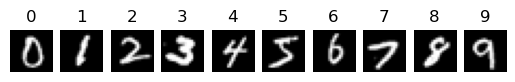

In [4]:
# Prepare the training data and test data including labels
#x is shaped like (50,100,20,20)
train = x[:,:50].reshape(-1,400).astype(np.float32)  # take first 50 columns (row,beginning:50), flatten each 20x20 cell into 400 element vector, make matrix of 2500,400
test = x[:,50:100].reshape(-1,400).astype(np.float32)  # Select remaining 50 columns (digit 5-9), flatten to (2500,400), convert to 32-bit float
# Create labels for train and test data. training data is data the model learns from. test data is data the model has never seen that we can use to see if the model learned from the pattern
print(train.size)
k = np.arange(10)  # Create array [0,1,2,...,9] for 10 digit classes
train_labels = np.repeat(k,250)[:,np.newaxis] #[0,0,0,0...1,1,1,...,9,9,9]
#Repeat() takes each element of an array and repeats it a certain number of times
#each digit 250 times and reshape to column vector (2500,1)
test_labels = train_labels.copy()  # Copy labels for test set (same distribution as training)

#sanity check: render random digits and their labels. There are 250 of each class.
for i in np.arange(10):  # Loop through each digit class
    plt.subplot(1, 10, i+1)  # Create subplot for digit i in 1x10 grid
    r = random.randint(i*250,(i+1)*250-1)  #pick random sample index within class i
    ri = train[r,:].reshape(20, 20)  # Reshape flattened 400-pixel vector back to 20x20 image
    plt.imshow(ri), plt.title(train_labels[r,0]), plt.axis('off')  # imshow renders the 20x20 image from ri as an image
plt.show();  #Render all subplots

## Visualize the feature space
The initial image features are the brightness values of all 20x20 pixels. In machine-learning terms, each image is a sample from a 400-dimensional feature space. Let's try to visualize this feature space. Experiment with different pixel locations in dim1 and dim2: pick some from the edges of the image, then some from more central locations. Interpret (i.e. understand) what the scatter plot distributions mean and briefly answer these questions:
1. What are the colors in the scatter plot?
Each color represents one digit class (0-9). The loop iterates 10 times with for i in range(10), and each iteration calls plt.scatter(train[y==i, dim1], train[y==i, dim2], label=str(i)). The boolean mask y==i selects all 250 samples where the label equals digit i, then plots their pixel brightnesses (dim1 vs dim2) with a unique color. The plt.legend() I added maps each color to its digit label.
2. Express in words what a data point at (0, 150) in this scatter plot looks like in the image space.
A data point at (0,150) in the below plto represents a digit image where pixel 204 (dim1) has brightness val of 0 and pixel 205 (dim2) has brightness val 150 (medium grey).
3. Why are there so many data points (dots) along the axes, at x=0 and x=255 and y=0 and y=255?
The image space is almost entirely black and white pixels, with a few intermediate gray values.
4. What would cause the data points for a specific color to be arranged perfectly along the diagonal (bottome left to top right)?
If the two pixels (dim1/dim2 in this case) have correlated brightness values (0,0,1,1,...,255,255), representing a linear diagonal across the scatter plot.


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[0 0 0 ... 9 9 9]
40.0
[ True  True  True ... False False False]
class 0: 250
[False False False ... False False False]
class 1: 250
[False False False ... False False False]
class 2: 250
[False False False ... False False False]
class 3: 250
[False False False ... False False False]
class 4: 250
[False False False ... False False False]
class 5: 250
[False False False ... False False False]
class 6: 250
[False False False ... False False False]
class 7: 250
[False False False ... False False False]
class 8: 250
[False False False ...  True  True  True]
class 9: 250


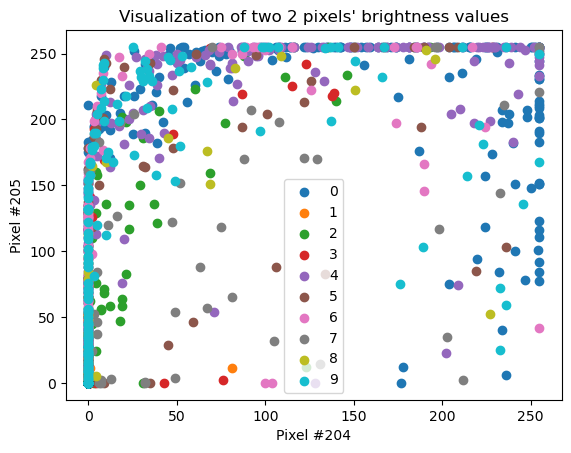

In [5]:
# Visualize the feature space
#train_labels is (2500,1) of 0 repeated to 9
#20x20 in image space -> 400 pixels in feature space from 20x20 where each pixel is the brightness of the given pixel (0-255 where 0 is black)
y = train_labels[:,0]  # Extract 1D array of class labels, makes it from 2500x1 to 1x2500. this flattens it
y_test = test_labels[:, 0]
print(train)
print(y)
dim1 = 204  # Choose first pixel dimension (pixel index 204 in flattened 400-d space)
dim2 = 205  # Choose second pixel dimension (pixel index 205 in flattened 400-d space)
print(train[0,150])
for i in range(10):  # Loop through each digit class (0-9)
    plt.scatter(train[y==i, dim1], train[y==i, dim2], label=str(i))  
    print(y==i)# Plot samples from class i using pixels dim1 and dim2 as x,y coordinates
    print(f'class {i}: {(y==i).sum()}')
plt.title("Visualization of two 2 pixels' brightness values")  # Title showing this is a 2D projection of 400D feature space
plt.xlabel(f'Pixel #{dim1}')  #X-axis label: first pixel index
plt.ylabel(f'Pixel #{dim2}')  #Y-axis label: second pixel index
plt.legend()
plt.show()  #Render scatter plot

### Visualize 3-, 4-, and 5-dimensional data
Render additional dimensions of the training data in the same plot. You will need to think of ways the additional dimensions can be displayed. Use color for the class label for the 3- and 4-dimensional rendering, as above. For the 5-dimensional rendering you can use color however you would like.

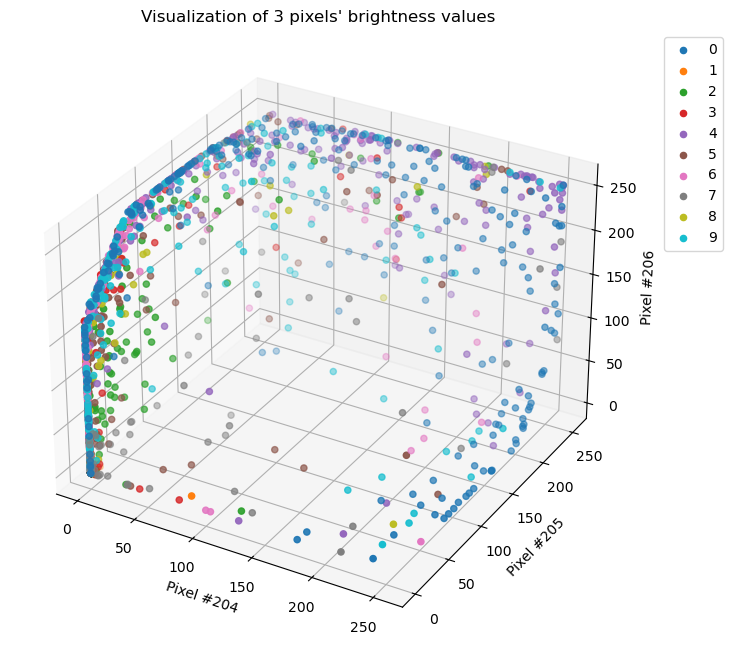

interactive(children=(IntSlider(value=100, description='dim4_range', max=255, step=10), Output()), _dom_classe…

interactive(children=(IntSlider(value=100, description='dim4_range', max=255, step=10), IntSlider(value=100, d…

<function __main__.plot_5d_pixels(dim4_range=100, dim5_range=100)>

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # Import 3D plotting toolkit
from ipywidgets import interact  # Import interactive widget library for Jupyter

dim1 = 204  
dim2 = 205  
dim3 = 206  # Third pixel dimension to visualize
dim4 = 207  # Fourth pixel dimension to visualize
dim5 = 208  # Fifth pixel dimension to visualize

y = train_labels[:,0]  #Extract 1D array of class labels, makes it from 2500x1 to 1x2500. this flattens it
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

for i in range(10):  #Loop through each digit class (0-9)
    ax.scatter(train[y==i, dim1], train[y==i, dim2], train[y==i,dim3], label=str(i))  

ax.set_xlabel(f'Pixel #{dim1}')
ax.set_ylabel(f'Pixel #{dim2}')
ax.set_zlabel(f'Pixel #{dim3}')
ax.set_title("Visualization of 3 pixels' brightness values")  
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()  #Render scatter plot

'''#example of interact purpose:
def f(x):
    return x
interact(f, x=10)'''

#4D visualization with interactive slider for dim4
def plot_4d_pixels(dim4_range=100):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection='3d')
    
    #Filter points where dim4 is within range of the slider value
    #Get the lower bound: dim4 value minus 25
    lower_bound = dim4_range - 25
    #Get the upper bound: dim4 value plus 25
    upper_bound = dim4_range + 25
    #Extract all dim4 values from the training data
    dim4_values = train[:, dim4] #all rows, column dim4
    #Create boolean mask where dim4 values are between lower and upper bounds 
    mask = (dim4_values >= lower_bound) & (dim4_values <= upper_bound)
    
    for i in range(10):
        filtered = train[mask & (y == i)]
        ax.scatter(filtered[:, dim1], filtered[:, dim2], filtered[:, dim3], label=str(i))
    
    ax.set_xlabel(f'Pixel #{dim1}')
    ax.set_ylabel(f'Pixel #{dim2}')
    ax.set_zlabel(f'Pixel #{dim3}')
    ax.set_title(f"4D Visualization (Pixel #{dim4} = {dim4_range})")
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 255)
    ax.set_zlim(0, 255)
    plt.show()

interact(plot_4d_pixels, dim4_range=(0, 255, 10)) #this moves the slider and shows how the 3d cross section of 4d space

def plot_5d_pixels(dim4_range=100, dim5_range=100):
    #Filter by dim4 and dim5 ranges
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection='3d')
    mask_dim4 = (train[:, dim4] >= dim4_range-25) &(train[:, dim4] <= dim4_range+25)
    mask_dim5 = (train[:, dim5] >= dim5_range-25) &(train[:, dim5] <= dim5_range+25)
    #combine both masks
    combined_mask = mask_dim4 & mask_dim5
    
    for i in range(10):
        filtered = train[combined_mask & (y == i)]
        ax.scatter(filtered[:, dim1], filtered[:, dim2], filtered[:, dim3], label=str(i))
    ax.set_xlabel(f'Pixel #{dim1}')
    ax.set_ylabel(f'Pixel #{dim2}')
    ax.set_zlabel(f'Pixel #{dim3}')
    ax.set_title(f"5D Visualization (Pixel #{dim4} = {dim4_range})")
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 255)
    ax.set_zlim(0, 255)
    plt.show()

interact(plot_5d_pixels, dim4_range=(0, 255, 10), dim5_range=(0, 255, 10))

### High-dimensional data spaces are sparse
As the dimensionality increases, there are fewer and fewer samples "nearby." Calculate the average distances between data points in pairs for 1-, 2-, and 3-dimensional spaces.
Then plot a graph that shows the average distance of uniformly distributed points over the dimensionality of the feature space.

(100, 3)


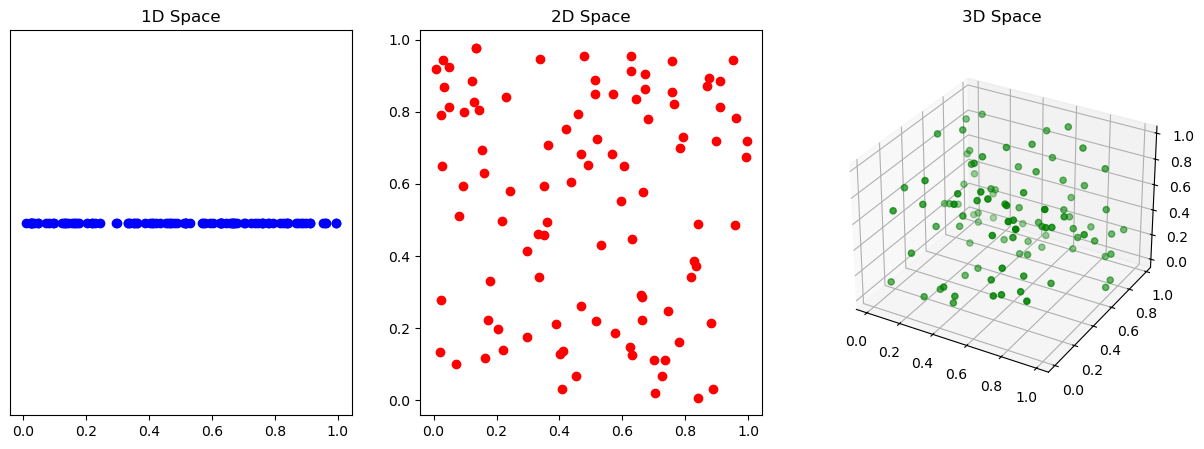

Average Euclidean distances in 1d, 2d, 3d:
1D: 0.33672997695695206
2D: 0.5381358541215463
3D: 0.6900851416008966


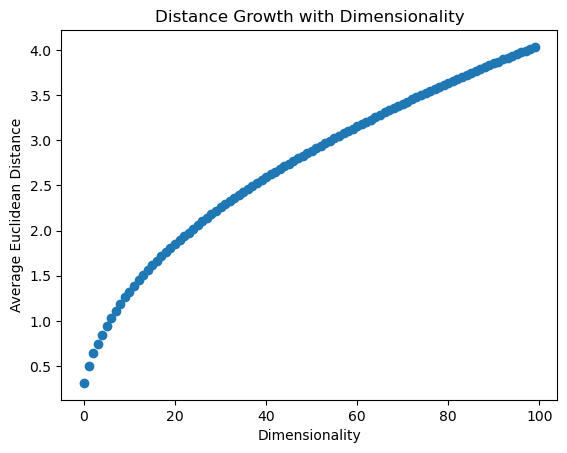

In [7]:
# Create a uniform distribution of points
n_points = 100  # Number of random points to generate

data_3d = np.random.rand(n_points, 3)  # Generate 100 random points in 3D [0,1] hypercube
print(data_3d.shape)
#Plot the first dimension, the first and second, and all three
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  #Create 1x3 subplot grid
axs[0].scatter(data_3d[:,0], np.zeros(n_points), color='blue')  #Plot 1D projection (first dimension only, all rows 0th col)
axs[0].set_title('1D Space')  #Set subplot title
axs[0].get_yaxis().set_visible(False)  #Hide y-axis 

axs[1].scatter(data_3d[:, 0], data_3d[:, 1], color='red')  #Plot 2D projection (first two dimensions)
axs[1].set_title('2D Space') 

ax_3d = fig.add_subplot(133, projection='3d')  #Create 3D subplot
ax_3d.scatter(data_3d[:, 0], data_3d[:, 1], data_3d[:, 2], color='green')  #Plot all 3D points
axs[2].axis('off')  #Hide axes for clarity
axs[2].set_title('3D Space')  #Set subplot title

plt.show() #Render all subplots

#What is the average euclidean distance between the points?
# Calculate the average distance for all data point pairs in 1d. Then for 2d. Then for 3d.
from scipy.spatial.distance import pdist  # Import pairwise distance calculation function
#pdist(X, metric='euclidean', *, out=None, **kwargs)
print("Average Euclidean distances in 1d, 2d, 3d:")
#1d
distances_1d = pdist(data_3d[:,:1],metric='euclidean')
avg_dist_1d = np.mean(distances_1d)
print(f'1D: {avg_dist_1d}')
#2d
distances_2d = pdist(data_3d[:,:2],metric='euclidean')
avg_dist_2d = np.mean(distances_2d)
print(f'2D: {avg_dist_2d}')
#3d
distances_3d = pdist(data_3d[:,:3],metric='euclidean')
avg_dist_3d = np.mean(distances_3d)
print(f'3D: {avg_dist_3d}')

#Plot a graph that relates the average euclidean distance to the feature space dimensionality.
ndim = 100  #Maximum dimensionality to test
data_highd = np.random.rand(n_points, ndim)  #Generate random points in 100D space
avg_dist = np.zeros(ndim)  #Array to store average distances for each dimensionality
for d in np.arange(ndim):  #Loop through each dimensionality
    distances = pdist(data_highd[:, :d+1],metric='euclidean') # calculate the dimension-dependent avg distance here
    avg_dist[d] = np.mean(distances)
plt.scatter(np.arange(ndim), avg_dist)  # Plot average distance vs dimensionality
plt.xlabel('Dimensionality')
plt.ylabel('Average Euclidean Distance')
plt.title('Distance Growth with Dimensionality')
plt.show()  # Render plot

### Subspaces and Manifolds
What makes a set of features good or bad for classification? Two key aspects are regularity in feature space and class-aligned discriminability. Let's start by looking at regularity because it helps us understand feature spaces, then come back to classification afterwards.

The idea of some regular structure that is inherent in the features of samples (the sample values) is typically referred to as "inherent dimensionality" and presumed _lower_ than the actual feature dimensionality (d=400 in our case). The feature subspace corresponding to the samples "weaves" through the higher-dimensional embedding in some regular fashion. This regularity is typically expressed as **manifolds**, subspaces that are more densly populated with samples than the rest of the feature space. Take a look at the images at the top of this page on
[manifolds](https://scikit-learn.org/stable/modules/manifold.html). While subspace methods are not the focus of this module, reading this entire page will give you a good introduction to those methods and their operation. Another great sample collection on [manifold learning](https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html) showcases different methods. 

We will use just one method for now, and transform the feature space onto a 2-dimensional subspace with a subspace embedding function that has been optimized for visualization of high-dimensional spaces, called **t-SNE**. This is a highly non-linear embedding, in contrast to PCA which we will learn about later. See the [sklearn t-SNE documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) or the  paper(s) by van der Maaten for details. Note that this transformation was estimted _without_ knowledge of the labels, yet the classes look reasonably well separated. 

c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\jgooh\anaconda3\envs\cs4330\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
       

<class 'numpy.ndarray'>


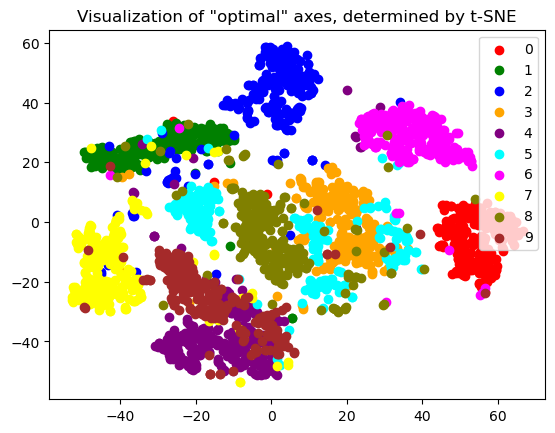

In [8]:
from sklearn.manifold import TSNE  # Import t-SNE dimensionality reduction algorithm
tsne = TSNE(n_components=2, random_state=0)  # Create t-SNE transformer for 2D embedding with fixed random seed
train_tsne = tsne.fit_transform(train)  #Apply t-SNE to 400D training data, output 2D coordinates
print(type(train_tsne))
# plt.scatter(train_tsne[:, 0], train_tsne[:, 1]) # no color distinction
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'olive', 'brown']  # Define color palette for 10 classes
for i in range(10):  # Loop through each digit class
    # color based on class label
    plt.scatter(train_tsne[y == i, 0], train_tsne[y == i, 1], label=str(i), color=colors[i])  # Plot class i samples with class-specific color
plt.title('Visualization of "optimal" axes, determined by t-SNE')  # Title showing non-linear dimensionality reduction
plt.legend()  # Display class label legend
plt.show()  # Render plot

### Questions
1. In this example of t-SNE as visualized above, what is the original feature dimensionality?
print(train.shape) -> 2500,400 -> 400 dimensions (each 20x20 image flattened to 400 pixels)
1. In this example of t-SNE as visualized above, what is the manifold dimensionality?
print(train_tsne.shape) -> 2500,2 -> 2 dimensions


## Feature-Space Modeling
Build a "supervised 10-means model" that models the training set after projection into 2D, `train_tsne`, by calculating the mean and variance for each of classes. That is, use the the values that t-SNE calculated from the original samples and the sample labels. Note that this is not classification yet.
## so we are going to label the mean (center point) at each digit class, separated by the label
1. Determine the 2-dimensional mean for every digit.
1. Add the mean as a color-coded X in the plot above. I used the scatterplot arguments `marker='X', s=500, edgecolor='black', linewidth=3`.
1. Determine two 1-dimensional variances for every digit and render an axis-aligned ellipsis, centered at the mean, where the ellipsis dimensions correspond to the 1-sigma variance in both dimensions.
1. Optional: calculate the eigenvectors (EV) of the covariance matrix instead and orient the elliptical rendering based on the EV directions.

1. Visually determine how well the distribution of samples is described by the mean and (co)variance. List issues you observe for _modeling_; do so explicitly, write it down:
-Long tails / outliers: Many classes have points far outside the 1-sigma ellipse (way beyond what a normal distribution would predict). Examples: digits 1, 4, 6, 9 all have scattered points far from their means.
-Non-Gaussian distributions: The actual point distributions aren't nice bell curves - they're irregular, patchy, and have gaps. The ellipse assumes a smooth spread
-Elongated/irregular cluster shapes: Some digits (like 1, green) form long stretched-out shapes
-Multiple sub-clusters: Some digit classes seem to have multiple separate groups 

1. Separately, list the issues that you anticipate will complicate _classification_ if mean and (co)variance are used as class model:
    -Digits 5,3,8 and others overlap so that may make classification difficult
    -Large variance: digit 5's huge ellipse covers areas where other digits live.
    -outliers from the mean may be misclassified
1. Can you think of a classifier that might achieve better accuracy for this data distribution (in 2d space) on the training data itself?
K-Nearest Neighbors classifier because it does not assume any particular distribution shape. It could handle the irregular cluster shapes, overlapping regions, and multiple sub-clusters by classifying based on proximity (using k=1 would give I belive 100% accuracy)

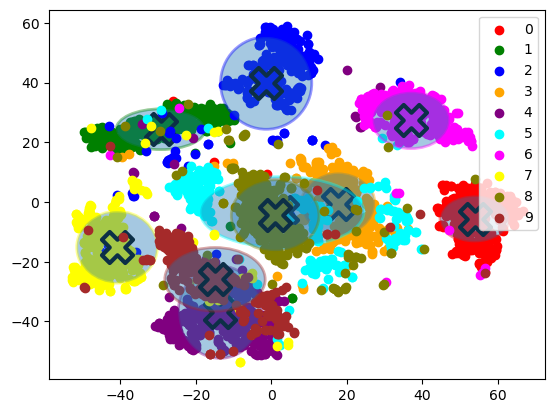

In [9]:
from matplotlib.patches import Ellipse
def plot_ellipse(ax,mean,cov,color): 
    """Helper function to visualize covariance ellipses"""
    #the cov matrix cov[given digit i] is 2x2, as covs is shape 10x2x2
    variance_x = cov[0,0]
    std_x = np.sqrt(variance_x) #std dev is sqrt of variance
    variance_y = cov[1,1]
    std_y = np.sqrt(variance_y)

    ellipse = Ellipse(xy=mean,width=2*std_x,height=2*std_y,
                      edgecolor=color, linewidth=2, alpha=0.4)
    ax.add_patch(ellipse)

def model10(Xset, labels):
    """Calculate mean and covariance for each of 10 digit classes"""
    means = np.zeros([10,2])  #Array to store 2D mean for each class
    covs = np.zeros([10,2,2])  #Array to store 2x2 covariance matrices for each class
    for i in range(10):  #loop through each digit class
        class_samples= Xset[labels==i] #only grab the rows where label ==i, 
        means[i] = np.mean(class_samples, axis=0) #axis=0 averages down the rows
        covs[i] = np.cov(class_samples,rowvar=False) #covariance measures the amount of which two variables vary together
        

        

    return means, covs
    
def plot10(Xset, labels, means, covs):
    """
    Scatter-plot the samples, then add means and (co)variances
    """
    colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'olive', 'brown']
    fig,ax = plt.subplots()

    for i in range(10):  # Loop through each class
        #Plot the samples (same as before)
        ax.scatter(Xset[labels == i, 0], Xset[labels == i, 1], 
                    label=str(i), color=colors[i])
        
        #Plot the mean as a big X
        plt.scatter(means[i, 0], means[i, 1], 
                    marker='X', s=500, edgecolor='black', linewidth=3, 
                    color=colors[i])  # Same color as the class
        plot_ellipse(ax,means[i],covs[i],colors[i])
    plt.legend()
    plt.show()

means, covs = model10(train_tsne, y)  # Train 10-means model on t-SNE projected training data
plot10(train_tsne, y,means, covs)  # Visualize data with learned means and covariances

## Classification
Next, use the 10-means model (which consists of `means` and `covs` in t-SNE space) to classify.
1. Write a function `classify10` that determines the nearest mean for every sample of the input sample matrix. Use the Euclidean distance at first. If you did not calculate covariances above, but only two 1-dimensional variances, you can use them instead for this function. The function should return the nearest class label (digit number) for every sample and the distance to the mean.
(Note that this function could be written to work for any dimensionality of the feature space, but this is not a requirement. It is ok for this function to take 2-dimensional features as input, more is not required for this assignment.)
1. Add an argument `dist="scaled"` to select the [scaled Euclidean](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.euclidean.html) distance instead.
1. Optional: Add the `dist="Mahalonobis"` argument option to calculate distance with the [Mahalanobis distance](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.mahalanobis.html) instead.
1. Classify the _projected training_ samples `train_tsne` first and calculate the accuracy for each of the two or three distance metrics.

In [10]:
from scipy.spatial.distance import euclidean, mahalanobis  # Import distance metric functions

#simple means-based classification function 
def classify10(means, covs, test_samples, dist='euclidean'):
    """Classify samples to nearest class mean using specified distance metric"""
    nearest_labels = []  #List to store predicted class label for each sample
    nearest_distances = []  #List to store distance to nearest mean for each sample
    for sample in test_samples:
        distances = [] #store euclidean distances for given digit class

        for i in range(10):
            if dist == 'euclidean':
                d = euclidean(sample,means[i])
            elif dist == 'scaled':
                #scaled euclidena: weight by inverse of standard devs
                #extracts the variances from diagonal of the covariance matrix
                variances = np.array([covs[i,0,0]],covs[i,1,1])
                d = euclidean(sample,means[i],w=1.0/variances)
            distances.append(d)

        nearest_class_index = np.argmin(distances) #returns the index of the min value
        nearest_dist = distances[nearest_class_index]
        nearest_labels.append(nearest_class_index)
        nearest_distances.append(nearest_dist)
    return np.array(nearest_labels), np.array(nearest_distances)  # Return predictions and distances as arrays

# Perform the classification and report the accuracy of classification 
# by comparing the classification result to the ground-truth labels
#Euclidean distance results
results_euc, dists_euc = classify10(means, covs, train_tsne, dist='euclidean')
accuracy_euc = np.sum(results_euc == y) / len(y)
print(f"Euclidean accuracy: {accuracy_euc} ({accuracy_euc*100:.2f}%)")

#Scaled Euclidean distance
results_scaled, dists_scaled = classify10(means, covs, train_tsne, dist='scaled')
accuracy_scaled = np.sum(results_scaled == y) / len(y)
print(f"Scaled Euclidean accuracy: {accuracy_scaled} ({accuracy_scaled*100:.2f}%)")

Euclidean accuracy: 0.7528 (75.28%)
Scaled Euclidean accuracy: 0.716 (71.60%)


### Classifying test samples in t-SNE space
1. Classify the _test_ samples by calling `tsne.fit_transform` and then classifying with the previously-learned model: `classify10(means, covs, train_tsne)`. You should reuse the model (means, covs) that was obtained from the training data; do not re-learn the model for the test data. 
1. Compare the performance and postulate reasons.
The test accuracy of 33% is much worse than the training accuracy of 75%. I am thinking this is because t-SNE creates a new coord system each time fit_transform() is called the means/cov calculated doesnt apply to the test coords.

Training accuracy: 75.28%
Test accuracy: 37.88%


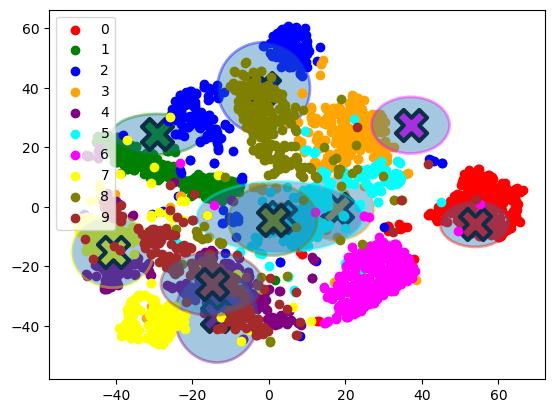

In [11]:
test_tsne = tsne.fit_transform(test) #apply t-SNE to test data

#Classify test data using training model
results_test, dists_test = classify10(means, covs, test_tsne, dist='euclidean')
accuracy_test = np.sum(results_test == y_test) / len(y_test)

print(f"Training accuracy: {accuracy_euc*100:.2f}%")
print(f"Test accuracy: {accuracy_test*100:.2f}%")

#visualize the test data with training model
plot10(test_tsne, y_test, means, covs)

## kNN Classification
Feature space modeling or subspace embedding is not inherently good for classification. It might help, but it has a different optimization objective that might also turn out detrimental to classification performance. Let us instead review methods that are explicitly built for classification.
Part of this lab came from this [tutorial on Optical Character Recognition (OCR)](https://docs.opencv.org/4.9.0/d8/d4b/tutorial_py_knn_opencv.html).

Questions/tasks:
1. Run this code in a loop with k={1, 3, ..., 19}. Report the accuracy for each k.

1. Why does the accuracy decrease with increasing k?
With a small k you are looking at closeset neighbors only and therefore these are more likely to be of the same digit class. When the k is large you may start to include neighbors from irrelevant neighbors/near a class boundary the larger k will pull in incorrect points dropping the class

In [12]:
# Initiate kNN, train it on the training data, then test it with the test data.
# Check the accuracy of classification by comparing the classification result 
# the ground-truth "test_labels"
knn = cv.ml.KNearest_create()  # Create k-Nearest Neighbors classifier
knn.train(train, cv.ml.ROW_SAMPLE, train_labels)  # Train kNN model on 400D training data with labels
for k in np.arange(1, 20, 2):  # Loop through k values: 1, 3, 5, ..., 19
    ret, result, neighbours, dist = knn.findNearest(test, k=k)  # Find k nearest neighbors for each test sample

    matches = result==test_labels  # Compare predictions to ground truth labels
    accuracy = np.count_nonzero(matches)/result.size  # Calculate accuracy as fraction of correct predictions
    print(f"{k}-NN accuracy: {accuracy} ({accuracy*100:.2f}%)")  # Print k-NN accuracy for this k value

1-NN accuracy: 0.92 (92.00%)
3-NN accuracy: 0.9164 (91.64%)
5-NN accuracy: 0.9176 (91.76%)
7-NN accuracy: 0.9144 (91.44%)
9-NN accuracy: 0.91 (91.00%)
11-NN accuracy: 0.91 (91.00%)
13-NN accuracy: 0.9084 (90.84%)
15-NN accuracy: 0.9072 (90.72%)
17-NN accuracy: 0.9016 (90.16%)
19-NN accuracy: 0.8996 (89.96%)


## Suitable feature spaces
List attributes of feature spaces that make them suitable to visual object classification, for example, for recognizing 10 different classes of digits.
- Samples of the same class should be "nearby" in feature space.
-different classes are well-separated
-samples should not be spread all over (low intra-class variance)
-different classes should be spread all over (high inter-class variance)
-stable clusters of features - avoid long tails or extreme outliers

Can you determine purely by looking at the feature space and sample distribution whether it will be good for classification? That is, actually visualize it, or calculate statistics on the feature space, without calculating an end-to-end metric like classification accuracy?
-i would say so, if the image is 2d/3d, we know we can plot the data (like brightness values) and see how the classes look. We could also at the intra and inter class variance metrics